In [1]:
import uproot 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns
import plotly.express as px
from matplotlib import colors
import math as math
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve

In [2]:
total_keys2 = ["L_MASS",'Lb_MASS','Jpsi_MASS','Jpsi_P', "Jpsi_PT",'Jpsi_CHI2','Jpsi_MAXDOCA','Jpsi_BPVDIRA','Jpsi_END_VRHO','Jpsi_END_VX','Jpsi_END_VY','Jpsi_END_VZ','Jpsi_BPVIP','Jpsi_MINIPCHI2','L_P','L_PT','L_PX','L_PY','L_PZ','L_CHI2',
               'L_END_VZ','L_END_VX','L_END_VY',"L_END_VRHO","L_BPVDIRA","L_BPVIP","L_BPVIPCHI2",'L_BPVFDCHI2','L_MINIPCHI2',"Lb_P","Lb_PT",'Lb_PX','Lb_PY','Lb_PZ',"Lb_CHI2","Lb_MAXDOCA","Lb_BPVDIRA","Lb_BPVVDRHO",
               "Lb_BPVIP",'Lb_BPVIPCHI2','Lb_BPVFDCHI2','Lb_MINIPCHI2',"p_P","p_PT",'p_PX','p_PY','p_PZ',"p_PID_P",
               "p_PID_K","p_MINIP",'p_GHOSTPROB',"pim_P","pim_PT",'pim_PX','pim_PY','pim_PZ','pim_GHOSTPROB','mum_P','mum_PT','mum_PX','mum_PY','mum_PZ','mum_CHI2','mum_GHOSTPROB','mum_PID_P','mum_PID_K','mum_PID_MU',
               'mum_PID_E','mum_MINIP','mum_MINIPCHI2','mup_P','mup_PT','mup_PX','mup_PY','mup_PZ','mup_CHI2','mup_GHOSTPROB','mup_PID_P','mup_PID_K','mup_PID_MU','mup_PID_E','mup_MINIP','mup_MINIPCHI2',
               'totCandidates','p_TRUEORIGIN_VZ', 'Lb_ETA', 'Jpsi_ETA', 'p_ETA', 'pim_ETA']

In [3]:
preselection_cut_mc = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) '

In [4]:
my_tuple_mc_1 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_2 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_3 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")
my_tuple_mc_4 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")

mc_data1 = my_tuple_mc_1.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'], library="pd", cut="(Lb_BKGCAT==0)")
mc_data2 = my_tuple_mc_2.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'],library="pd", cut="(Lb_BKGCAT==0)")
mc_data3 = my_tuple_mc_1.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'], library="pd", cut="(Lb_BKGCAT!=0)")
mc_data4 = my_tuple_mc_2.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'],library="pd", cut="(Lb_BKGCAT!=0)")

mc_data5 = my_tuple_mc_3.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'], library="pd", cut="(Lb_BKGCAT==0)")
mc_data6 = my_tuple_mc_4.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'],library="pd", cut="(Lb_BKGCAT==0)")
mc_data7 = my_tuple_mc_3.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'], library="pd", cut="(Lb_BKGCAT!=0)")
mc_data8 = my_tuple_mc_4.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'],library="pd", cut="(Lb_BKGCAT!=0)")

mc_signal_up = pd.merge(mc_data1, mc_data2, how="outer")
mc_signal_down = pd.merge(mc_data5, mc_data6, how="outer")
mc_signal_merge = pd.merge(mc_signal_up, mc_signal_down, how="outer")

mc_background_up = pd.merge(mc_data3, mc_data4, how="outer")
mc_background_down = pd.merge(mc_data7, mc_data8, how="outer")
mc_background_merge = pd.merge(mc_background_up, mc_background_down, how="outer")

mc_signal_background_merge = pd.merge(mc_signal_merge, mc_background_merge, how="outer")


mc_background = mc_background_merge.query(preselection_cut_mc)

mc_data_preselection = mc_signal_background_merge.query(preselection_cut_mc)
mc_data = mc_signal_background_merge
mc_signal = mc_signal_merge

In [5]:
#Creates a new variables like the Cos()...
sum_CHI2 = mc_signal['Lb_CHI2']+mc_signal['L_CHI2']+mc_signal['Jpsi_CHI2']
angle = np.arccos((mc_signal['mum_PX']*mc_signal['mup_PX']+mc_signal['mum_PY']*mc_signal['mup_PY']+mc_signal['mum_PZ']*mc_signal['mup_PZ'])/(mc_signal['mum_P']*mc_signal['mup_P']))
cos_angle = ((mc_signal['mum_PX']*mc_signal['mup_PX']+mc_signal['mum_PY']*mc_signal['mup_PY']+mc_signal['mum_PZ']*mc_signal['mup_PZ'])/(mc_signal['mum_P']*mc_signal['mup_P']))
cos_xi_L = ((mc_signal['p_PX']*mc_signal['L_PX']+mc_signal['p_PY']*mc_signal['L_PY']+mc_signal['p_PZ']*mc_signal['L_PZ'])/(mc_signal['p_P']*mc_signal['L_P']))
cos_xi_Lb = ((mc_signal['p_PX']*mc_signal['Lb_PX']+mc_signal['p_PY']*mc_signal['Lb_PY']+mc_signal['p_PZ']*mc_signal['Lb_PZ'])/(mc_signal['p_P']*mc_signal['Lb_P']))
xi_LbP = np.arccos(cos_xi_Lb)
xi_LP = np.arccos(cos_xi_L)

#Add the new varaibles to signal_data
mc_signal['SUMCHI2'] = sum_CHI2
mc_signal['Theta_P'] = angle
mc_signal['Cos_theta_P'] = cos_angle
mc_signal['Cos_xi_LP'] = cos_xi_L
mc_signal['Cos_xi_LbP'] = cos_xi_Lb
mc_signal['xi_LP'] = xi_LbP
mc_signal['xi_LbP'] = xi_LP

mc_signal_preselection = mc_signal.query(preselection_cut_mc)

/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/javeser/ipykernel_19873/3576386377.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_signal['SUMCHI2'] = sum_CHI2
/tmp/javeser/ipykernel_19873/3576386377.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_signal['Theta_P'] = angle
/tmp/javeser/ipykernel_19873/3576386377.py:13: PerformanceWarning: DataFrame is highly fragmented.  T

In [6]:
mc_signal


,L_MASS,Lb_MASS,Jpsi_MASS,Jpsi_P,Jpsi_PT,Jpsi_CHI2,Jpsi_MAXDOCA,Jpsi_BPVDIRA,Jpsi_END_VRHO,Jpsi_END_VX,...,pim_TRACK_POS_CLOSESTTOBEAM_Y,pim_TRACK_POS_CLOSESTTOBEAM_Z,L_BKGCAT,SUMCHI2,Theta_P,Cos_theta_P,Cos_xi_LP,Cos_xi_LbP,xi_LP,xi_LbP
0,1078.259033,5257.361816,3014.794678,145656.640625,6167.957520,0.607561,0.013176,0.999846,1.118636,1.0240,...,-192.9450,7826.0991,0,4.277021,0.043999,0.999032,0.999827,0.999684,0.025122,0.018593
1,1078.339722,5113.678223,3095.833740,134008.062500,1783.741333,0.198718,0.011110,0.999999,0.680625,0.3610,...,105.4484,7826.0991,0,3.853298,0.047498,0.998872,1.000000,0.999541,0.030306,NaN
2,1078.478394,5378.423828,3104.240234,107524.718750,6373.708984,0.386113,0.031794,0.999907,1.743110,1.5966,...,-336.3848,7826.0991,0,1.265592,0.156578,0.987767,0.999999,0.999912,0.013256,0.001145
3,1078.545044,5452.856934,3114.653809,75249.507812,12491.000000,2.606676,0.030760,0.998852,1.256283,1.1800,...,-344.7611,7826.0991,0,22.678582,0.095915,0.995404,0.999990,0.999183,0.040418,0.004367
4,1078.846558,5150.160645,3109.953369,58382.671875,2565.219727,1.778421,0.030807,0.999737,1.657983,1.5057,...,218.3457,7895.8999,0,5.225974,0.110724,0.993876,0.999997,0.999598,0.028365,0.002367
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54384,5717.023926,6354.849121,3086.857178,135420.625000,5170.177246,2.505193,0.029310,0.999964,2.466711,2.4469,...,10.8635,7826.0991,0,191.853399,0.064420,0.997926,0.999917,0.999883,0.015317,0.012919
54385,5839.427246,6388.020996,3092.033691,89363.710938,5365.817871,0.007249,0.003690,0.999882,1.182210,1.1660,...,-332.1305,7826.0991,0,0.596474,0.131838,0.991322,0.999989,0.999942,0.010770,0.004784
54386,6044.197266,5397.795410,3134.453125,76237.843750,3029.752686,5.509789,0.058464,0.999985,1.562943,1.5499,...,-146.1213,7826.0991,0,28.536086,0.092173,0.995755,0.999989,0.999925,0.012217,0.004645
54387,6181.660156,6212.480469,3076.550781,56612.843750,6028.994141,1.577732,0.027083,0.999847,0.563703,0.4521,...,-164.3406,7826.0991,0,19.413300,0.108579,0.994111,0.999968,0.999446,0.033284,0.008038


In [7]:
mc_signal_preselection

,L_MASS,Lb_MASS,Jpsi_MASS,Jpsi_P,Jpsi_PT,Jpsi_CHI2,Jpsi_MAXDOCA,Jpsi_BPVDIRA,Jpsi_END_VRHO,Jpsi_END_VX,...,pim_TRACK_POS_CLOSESTTOBEAM_Y,pim_TRACK_POS_CLOSESTTOBEAM_Z,L_BKGCAT,SUMCHI2,Theta_P,Cos_theta_P,Cos_xi_LP,Cos_xi_LbP,xi_LP,xi_LbP
0,1078.259033,5257.361816,3014.794678,145656.640625,6167.957520,0.607561,0.013176,0.999846,1.118636,1.0240,...,-192.9450,7826.0991,0,4.277021,0.043999,0.999032,0.999827,0.999684,0.025122,0.018593
2,1078.478394,5378.423828,3104.240234,107524.718750,6373.708984,0.386113,0.031794,0.999907,1.743110,1.5966,...,-336.3848,7826.0991,0,1.265592,0.156578,0.987767,0.999999,0.999912,0.013256,0.001145
3,1078.545044,5452.856934,3114.653809,75249.507812,12491.000000,2.606676,0.030760,0.998852,1.256283,1.1800,...,-344.7611,7826.0991,0,22.678582,0.095915,0.995404,0.999990,0.999183,0.040418,0.004367
4,1078.846558,5150.160645,3109.953369,58382.671875,2565.219727,1.778421,0.030807,0.999737,1.657983,1.5057,...,218.3457,7895.8999,0,5.225974,0.110724,0.993876,0.999997,0.999598,0.028365,0.002367
5,1079.165283,5041.642090,3112.403564,41376.492188,932.566772,0.463860,0.022380,0.999824,2.472209,1.9035,...,325.4154,7826.0991,0,3.746577,0.158658,0.987440,0.999997,0.999886,0.015090,0.002367
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44646,1499.633911,5674.447754,3064.945312,155518.343750,3516.810303,0.000019,0.000073,0.999937,0.830759,0.7244,...,-305.5299,7826.0991,0,1.695880,0.043062,0.999073,0.999926,0.999859,0.016787,0.012158
44647,1499.803101,5975.576172,3087.941650,99037.742188,9127.812500,3.153563,0.019495,0.999875,8.873328,4.1159,...,1002.3088,7826.0991,0,3.833394,0.066682,0.997778,0.999925,0.999098,0.042478,0.012280
44648,1499.808228,5661.456055,3092.985840,94886.578125,6551.219727,0.051348,0.004174,0.999868,1.650362,1.6323,...,48.6645,7826.0991,0,5.132070,0.065019,0.997887,0.999769,0.999375,0.035361,0.021510
44649,1499.829712,5790.564453,3083.994141,122750.835938,9909.113281,3.749646,0.024744,0.999897,2.043518,-1.8034,...,-78.4485,7826.0991,0,6.896855,0.051998,0.998648,0.999892,0.999757,0.022049,0.014718


In [8]:
model = CatBoostClassifier().load_model("new_BDT")
prob = model.predict_proba(mc_signal_preselection)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
mc_signal_preselection['prob1'] = signal_MVA_probs
mc_signal_BDT = mc_signal_preselection.query('prob1 > 0.99')

[[1.07879398e-02 9.89212060e-01]
 [9.11279631e-05 9.99908872e-01]
 [7.60039894e-02 9.23996011e-01]
 ...
 [3.44294286e-01 6.55705714e-01]
 [3.70603146e-04 9.99629397e-01]
 [1.92033714e-02 9.80796629e-01]]


/tmp/javeser/ipykernel_19873/4274407715.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_signal_preselection['prob1'] = signal_MVA_probs
/tmp/javeser/ipykernel_19873/4274407715.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal_preselection['prob1'] = signal_MVA_probs


In [9]:
from rk_transport import FarRKTrkTransport, propagate_to_vertex

def propagate_to_vertex(vz, xi, yi, zi, pxi, pyi, pzi, qoverp,rk):
    xf,yf,txf,tyf = rk.propagate(vz/10., 1., xi/10., yi/10., zi/10., pxi/1000., pyi/1000., pzi/1000., qoverp*1000.)
    mom = np.array([txf,tyf,1])*((np.abs(1/(qoverp*1000.)))/np.sqrt(txf**2. + tyf**2. + 1.))
    return mom[0]*1000., mom[1]*1000., mom[2]*1000., xf*10., yf*10.

rk = FarRKTrkTransport()

vertex_values = pd.DataFrame(columns=['p_PX_V','p_PY_V','p_PZ_V','p_X_V','p_Y_V'])
vertex_values2 = pd.DataFrame(columns=['pim_PX_V','pim_PY_V','pim_PZ_V','pim_X_V','pim_Y_V'])

vertex_values[['p_PX_V','p_PY_V','p_PZ_V','p_X_V','p_Y_V']] = mc_signal_BDT.apply(lambda row: propagate_to_vertex(row.L_END_VZ,row.p_TRACK_POS_CLOSESTTOBEAM_X,row.p_TRACK_POS_CLOSESTTOBEAM_Y,row.p_TRACK_POS_CLOSESTTOBEAM_Z,row.p_PX,row.p_PY,row.p_PZ,row.p_QOVERP,rk),axis='columns',result_type='expand')
vertex_values2[['pim_PX_V','pim_PY_V','pim_PZ_V','pim_X_V','pim_Y_V']] = mc_signal_BDT.apply(lambda row: propagate_to_vertex(row.L_END_VZ,row.pim_TRACK_POS_CLOSESTTOBEAM_X,row.pim_TRACK_POS_CLOSESTTOBEAM_Y,row.pim_TRACK_POS_CLOSESTTOBEAM_Z,row.pim_PX,row.pim_PY,row.pim_PZ,row.pim_QOVERP,rk),axis='columns',result_type='expand')

mc_signal_BDT = pd.concat([mc_signal_BDT,vertex_values],axis='columns')
mc_signal_BDT = pd.concat([mc_signal_BDT,vertex_values2],axis='columns')


FarRKTrkTransport: reading B field mapping from file /l/javeser/farvertexing/db/MagneticFieldMapping20x20x100.root
FarRKTrkTransport: reading B field mapping with: x in [-300,300] and 21 points
                                                 y in [-300,300] and 21 points
                                                 z in [0,1000] and 101 points


In [10]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd

particulas = ' (p_QOVERP > 0) & (pim_QOVERP < 0 )'
antiparticulas = ' (p_QOVERP < 0) & (pim_QOVERP > 0)'

mc_signal1 = mc_signal_BDT.query(particulas)
mc_signal2 = mc_signal_BDT.query(antiparticulas)

def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector 
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    pV0 = pV0_4.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus
    
    return alpha, pT

def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Sumar los cuadrimomentos
    total_momentum = pplus_4 + pminus_4
    
    # Calcular la masa invariante
    invariant_mass = total_momentum.M()
    invariant_mass_pion = pminus_4.M()
    invariant_mass_proton = pplus_4.M()
    invariant_mass_lambda = pV0_4.M()
    
    return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# Inicializar columnas para almacenar los resultados
mc_signal_BDT['alpha'] = np.nan
mc_signal_BDT['pT'] = np.nan
mc_signal_BDT['alpha_anti'] = np.nan
mc_signal_BDT['pT_anti'] = np.nan

# Calcular para partículas
particle = True
results = []
# results_mass = []
# results_mass_p = []
# results_mass_pion = []
# results_mass_lambda = []

for index, row in mc_signal1.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    mc_signal_BDT.at[index, 'alpha'] = alpha
    mc_signal_BDT.at[index, 'pT'] = pT
    # results_mass.append(mass)
    # results_mass_p.append(mass_p)
    # results_mass_pion.append(mass_pion)
    # results_mass_lambda.append(mass_lambda)

# Convertir resultados a DataFrame
armenteros_particle_mc_ext = pd.DataFrame(results, columns=['alpha', 'pT'])
# invariant_mass_particle = pd.DataFrame(results_mass, columns=['mass'])
# invariant_mass_particle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
# invariant_mass_particle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
# invariant_mass_particle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# Calcular para antipartículas
particle = False
results = []  # Reinicializar la lista de resultados
# results_mass = []  # Reinicializar la lista de masas
# results_mass_p = []
# results_mass_pion = []
# results_mass_lambda = []

for index, row in mc_signal2.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    mc_signal_BDT.at[index, 'alpha_anti'] = alpha
    mc_signal_BDT.at[index, 'pT_anti'] = pT
    # results_mass.append(mass)
    # results_mass_p.append(mass_p)
    # results_mass_pion.append(mass_pion)
    # results_mass_lambda.append(mass_lambda)

# # Convertir resultados a DataFrame
armenteros_antiparticle_mc_ext = pd.DataFrame(results, columns=['alpha_anti', 'pT_anti'])
# invariant_mass_antiparticle = pd.DataFrame(results_mass, columns=['mass'])
# invariant_mass_antiparticle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
# invariant_mass_antiparticle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
# invariant_mass_antiparticle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# Combine alpha and alpha_anti into a single column without overwriting
mc_signal_BDT['alpha_combined'] = mc_signal_BDT['alpha'].combine_first(mc_signal_BDT['alpha_anti'])
mc_signal_BDT['pT_combined'] = mc_signal_BDT['pT'].combine_first(mc_signal_BDT['pT_anti'])

# Mostrar resultados
# print("Partículas:")
# print(armenteros_particle)
# # print("\nMasa invariante de la Lambda:")
# # print(invariant_mass_particle)
# # print("\nMasa invariante del Proton:")
# # print(invariant_mass_particle_p)
# # print("\nMasa invariante del Pion:")
# # print(invariant_mass_particle_pion)

# print("\nAntipartículas:")
# print(armenteros_antiparticle)
# # print("\nMasa invariante de la Anti-Lambda:")
# # print(invariant_mass_antiparticle)
# # print("\nMasa invariante del Anti-Proton:")
# # print(invariant_mass_antiparticle_p)
# # print("\nMasa invariante del Anti-Pion:")
# # print(invariant_mass_antiparticle_pion)


Welcome to JupyROOT 6.30/04


In [11]:
 mc_signal_preselection['p_TRUEORIGIN_VZ']

0        3857.3295
2        6329.0396
3        6374.6523
4        7806.2830
5        6861.9199
           ...    
44646    2233.0392
44647    5875.2626
44648    1903.1285
44649    4275.5228
44650    2184.6422
Name: p_TRUEORIGIN_VZ, Length: 33400, dtype: float64

In [12]:
mc_signal['p_TRUEORIGIN_VZ']

0        3857.3295
1        7372.7539
2        6329.0396
3        6374.6523
4        7806.2830
           ...    
54384    1088.8533
54385    2030.7342
54386     724.2034
54387    3065.5567
54388    1410.8260
Name: p_TRUEORIGIN_VZ, Length: 54389, dtype: float64

In [13]:
from rk_transport import FarRKTrkTransport, propagate_to_vertex

def propagate_to_vertex(vz, xi, yi, zi, pxi, pyi, pzi, qoverp,rk):
    xf,yf,txf,tyf = rk.propagate(vz/10., 1., xi/10., yi/10., zi/10., pxi/1000., pyi/1000., pzi/1000., qoverp*1000.)
    mom = np.array([txf,tyf,1])*((np.abs(1/(qoverp*1000.)))/np.sqrt(txf**2. + tyf**2. + 1.))
    return mom[0]*1000., mom[1]*1000., mom[2]*1000., xf*10., yf*10.

rk = FarRKTrkTransport()

vertex_values = pd.DataFrame(columns=['p_PX_V','p_PY_V','p_PZ_V','p_X_V','p_Y_V'])
vertex_values2 = pd.DataFrame(columns=['pim_PX_V','pim_PY_V','pim_PZ_V','pim_X_V','pim_Y_V'])

vertex_values[['p_PX_V','p_PY_V','p_PZ_V','p_X_V','p_Y_V']] = mc_signal_preselection.apply(lambda row: propagate_to_vertex(row.L_END_VZ,row.p_TRACK_POS_CLOSESTTOBEAM_X,row.p_TRACK_POS_CLOSESTTOBEAM_Y,row.p_TRACK_POS_CLOSESTTOBEAM_Z,row.p_PX,row.p_PY,row.p_PZ,row.p_QOVERP,rk),axis='columns',result_type='expand')
vertex_values2[['pim_PX_V','pim_PY_V','pim_PZ_V','pim_X_V','pim_Y_V']] = mc_signal_preselection.apply(lambda row: propagate_to_vertex(row.L_END_VZ,row.pim_TRACK_POS_CLOSESTTOBEAM_X,row.pim_TRACK_POS_CLOSESTTOBEAM_Y,row.pim_TRACK_POS_CLOSESTTOBEAM_Z,row.pim_PX,row.pim_PY,row.pim_PZ,row.pim_QOVERP,rk),axis='columns',result_type='expand')

mc_signal_preselection = pd.concat([mc_signal_preselection,vertex_values],axis='columns')
mc_signal_preselection = pd.concat([mc_signal_preselection,vertex_values2],axis='columns')


FarRKTrkTransport: reading B field mapping from file /l/javeser/farvertexing/db/MagneticFieldMapping20x20x100.root
FarRKTrkTransport: reading B field mapping with: x in [-300,300] and 21 points
                                                 y in [-300,300] and 21 points
                                                 z in [0,1000] and 101 points


In [14]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd

particulas = ' (p_QOVERP > 0) & (pim_QOVERP < 0 )'
antiparticulas = ' (p_QOVERP < 0) & (pim_QOVERP > 0)'

mc_signal1 = mc_signal_preselection.query(particulas)
mc_signal2 = mc_signal_preselection.query(antiparticulas)

def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector 
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    pV0 = pV0_4.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus
    
    return alpha, pT

def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Sumar los cuadrimomentos
    total_momentum = pplus_4 + pminus_4
    
    # Calcular la masa invariante
    invariant_mass = total_momentum.M()
    invariant_mass_pion = pminus_4.M()
    invariant_mass_proton = pplus_4.M()
    invariant_mass_lambda = pV0_4.M()
    
    return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# Inicializar columnas para almacenar los resultados
mc_signal_preselection['alpha'] = np.nan
mc_signal_preselection['pT'] = np.nan
mc_signal_preselection['alpha_anti'] = np.nan
mc_signal_preselection['pT_anti'] = np.nan

# Calcular para partículas
particle = True
results = []
# results_mass = []
# results_mass_p = []
# results_mass_pion = []
# results_mass_lambda = []

for index, row in mc_signal1.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    mc_signal_preselection.at[index, 'alpha'] = alpha
    mc_signal_preselection.at[index, 'pT'] = pT
    # results_mass.append(mass)
    # results_mass_p.append(mass_p)
    # results_mass_pion.append(mass_pion)
    # results_mass_lambda.append(mass_lambda)

# Convertir resultados a DataFrame
armenteros_particle_mc_ext = pd.DataFrame(results, columns=['alpha', 'pT'])
# invariant_mass_particle = pd.DataFrame(results_mass, columns=['mass'])
# invariant_mass_particle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
# invariant_mass_particle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
# invariant_mass_particle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# Calcular para antipartículas
particle = False
results = []  # Reinicializar la lista de resultados
# results_mass = []  # Reinicializar la lista de masas
# results_mass_p = []
# results_mass_pion = []
# results_mass_lambda = []

for index, row in mc_signal2.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    mc_signal_preselection.at[index, 'alpha_anti'] = alpha
    mc_signal_preselection.at[index, 'pT_anti'] = pT
    # results_mass.append(mass)
    # results_mass_p.append(mass_p)
    # results_mass_pion.append(mass_pion)
    # results_mass_lambda.append(mass_lambda)

# # Convertir resultados a DataFrame
armenteros_antiparticle_mc_ext = pd.DataFrame(results, columns=['alpha_anti', 'pT_anti'])
# invariant_mass_antiparticle = pd.DataFrame(results_mass, columns=['mass'])
# invariant_mass_antiparticle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
# invariant_mass_antiparticle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
# invariant_mass_antiparticle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# Combine alpha and alpha_anti into a single column without overwriting
mc_signal_preselection['alpha_combined'] = mc_signal_preselection['alpha'].combine_first(mc_signal_preselection['alpha_anti'])
mc_signal_preselection['pT_combined'] = mc_signal_preselection['pT'].combine_first(mc_signal_preselection['pT_anti'])

# Mostrar resultados
# print("Partículas:")
# print(armenteros_particle)
# # print("\nMasa invariante de la Lambda:")
# # print(invariant_mass_particle)
# # print("\nMasa invariante del Proton:")
# # print(invariant_mass_particle_p)
# # print("\nMasa invariante del Pion:")
# # print(invariant_mass_particle_pion)

# print("\nAntipartículas:")
# print(armenteros_antiparticle)
# # print("\nMasa invariante de la Anti-Lambda:")
# # print(invariant_mass_antiparticle)
# # print("\nMasa invariante del Anti-Proton:")
# # print(invariant_mass_antiparticle_p)
# # print("\nMasa invariante del Anti-Pion:")
# # print(invariant_mass_antiparticle_pion)


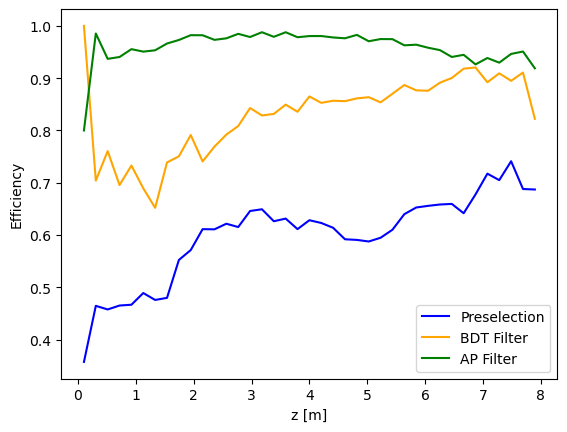

In [17]:
import numpy as np
import matplotlib.pyplot as plt

mc_signal_BDT = mc_signal_preselection.query('(prob1) > 0.95')
mc_signal_AP = mc_signal_BDT.loc[(abs(mc_signal_preselection['alpha_combined']) > 0.45)]
# mc_signal_AP = mc_signal_preselection.loc[(abs(mc_signal_preselection['alpha_combined']) > 0.45) & mc_signal_preselection['prob1'] > 0.99]

fig, ax = plt.subplots()

# Variable y bins
variable = 'p_TRUEORIGIN_VZ'
bins = np.linspace(0, 8000, 40)
bin_centres = 0.5 * (bins[1:] + bins[:-1])/1000

# Calcular histogramas
numerator_hist1, _ = np.histogram(mc_signal_preselection[variable], bins)
denominator_hist1, _ = np.histogram(mc_signal[variable], bins)

numerator_hist2, _ = np.histogram(mc_signal_BDT[variable], bins)
denominator_hist2, _ = np.histogram(mc_signal_preselection[variable], bins)

numerator_hist3, _ = np.histogram(mc_signal_AP[variable], bins)
denominator_hist3, _ = np.histogram(mc_signal_BDT[variable], bins)

# Evitar división por cero
with np.errstate(divide='ignore', invalid='ignore'):
    ratio1 = np.divide(numerator_hist1, denominator_hist1, where=denominator_hist1 != 0)
    ratio1_errors = np.sqrt((np.sqrt(numerator_hist1) / numerator_hist1) ** 2 + (np.sqrt(denominator_hist1) / denominator_hist1) ** 2)
    ratio1[denominator_hist1 == 0] = 0
    ratio1_errors[denominator_hist1 == 0] = 0

    ratio2 = np.divide(numerator_hist2, denominator_hist2, where=denominator_hist2 != 0)
    ratio2_errors = np.sqrt((np.sqrt(numerator_hist2) / numerator_hist2) ** 2 + (np.sqrt(denominator_hist2) / denominator_hist2) ** 2)
    ratio2[denominator_hist2 == 0] = 0
    ratio2_errors[denominator_hist2 == 0] = 0

    ratio3 = np.divide(numerator_hist3, denominator_hist3, where=denominator_hist3 != 0)
    ratio3_errors = np.sqrt((np.sqrt(numerator_hist3) / numerator_hist3) ** 2 + (np.sqrt(denominator_hist3) / denominator_hist3) ** 2)
    ratio3[denominator_hist3 == 0] = 0
    ratio3_errors[denominator_hist3 == 0] = 0

# Graficar líneas
ax.plot(bin_centres, ratio1, label="Preselection", color='blue')
ax.plot(bin_centres, ratio2, label="BDT Filter", color='orange')
ax.plot(bin_centres, ratio3, label="AP Filter", color='green')

# Ajustes del gráfico
ax.legend(fontsize=10)
ax.set_xlabel('z [m]', fontsize=10)
ax.set_ylabel('Efficiency')
ax.tick_params(axis='both', which='major', labelsize=10)

# Mostrar el gráfico
plt.show()
